<a href="https://colab.research.google.com/github/agatastachowiak/wearable-stress-detection/blob/main/notebooks/02_multi_subject_pipeline_and_modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Download/unzip data

import os
os.makedirs('/root/wesad_data', exist_ok=True)
!wget -O /root/wesad_data/WESAD.zip "https://uni-siegen.sciebo.de/s/HGdUkoNlW1Ub0Gx/download"
!unzip -q /root/wesad_data/WESAD.zip -d /root/wesad_data/

--2026-09-11 10:05:13--  https://uni-siegen.sciebo.de/s/HGdUkoNlW1Ub0Gx/download
Resolving uni-siegen.sciebo.de (uni-siegen.sciebo.de)... 128.176.1.4
Connecting to uni-siegen.sciebo.de (uni-siegen.sciebo.de)|128.176.1.4|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://uni-siegen.sciebo.de/public.php/dav/files/HGdUkoNlW1Ub0Gx [following]
--2026-09-11 10:05:14--  https://uni-siegen.sciebo.de/public.php/dav/files/HGdUkoNlW1Ub0Gx
Reusing existing connection to uni-siegen.sciebo.de:443.
HTTP request sent, awaiting response... 200 OK
Length: 2249444501 (2.1G) [application/zip]
Saving to: ‘/root/wesad_data/WESAD.zip’

/root/wesad_data/WE 100%[===================>]   2.09G  36.7MB/s    in 61s     

2026-09-11 10:06:15 (35.0 MB/s) - ‘/root/wesad_data/WESAD.zip’ saved [2249444501/2249444501]



In [4]:
# Load in the data
import pickle

with open('/root/wesad_data/WESAD/S2/S2.pkl', 'rb') as f:
    data = pickle.load(f, encoding='latin1')

print("Loaded. Keys:", data.keys())

Loaded. Keys: dict_keys(['signal', 'label', 'subject'])


In [5]:
import numpy as np

def extract_windows(data, window_sec=60, step_sec=60):
    """
    Slices one subject's session into fixed-length windows, keeps only windows
    that fall cleanly within one condition (baseline/stress/amusement), and
    extracts simple summary features from each wrist sensor signal.
    """
    labels = data['label']
    fs_label = 700  # labels are sampled at 700 Hz, per the readme

    # Wrist signals, each at its own documented sampling rate
    eda = data['signal']['wrist']['EDA'].flatten()
    bvp = data['signal']['wrist']['BVP'].flatten()
    temp = data['signal']['wrist']['TEMP'].flatten()
    acc = data['signal']['wrist']['ACC']  # shape: (samples, 3) -- x/y/z axes

    fs_eda, fs_bvp, fs_temp, fs_acc = 4, 64, 4, 32

    total_duration_sec = len(labels) / fs_label
    n_windows = int(total_duration_sec // step_sec)

    features = []
    window_labels = []

    for i in range(n_windows):
        t_start = i * step_sec
        t_end = t_start + window_sec

        # --- Check this window's label purity ---
        l_start, l_end = int(t_start * fs_label), int(t_end * fs_label)
        label_window = labels[l_start:l_end]
        if len(label_window) == 0:
            continue

        vals, counts = np.unique(label_window, return_counts=True)
        dominant_label = vals[np.argmax(counts)]
        purity = counts.max() / len(label_window)

        # Only keep clean windows of baseline(1)/stress(2)/amusement(3)
        if dominant_label not in [1, 2, 3] or purity < 0.9:
            continue

        # Slice each signal to the same time window, using its own sampling rate
        eda_win = eda[int(t_start*fs_eda):int(t_end*fs_eda)]
        bvp_win = bvp[int(t_start*fs_bvp):int(t_end*fs_bvp)]
        temp_win = temp[int(t_start*fs_temp):int(t_end*fs_temp)]
        acc_win = acc[int(t_start*fs_acc):int(t_end*fs_acc)]

        if len(eda_win) == 0 or len(bvp_win) == 0 or len(temp_win) == 0 or len(acc_win) == 0:
            continue

        # Acceleration magnitude: combines x/y/z into overall movement intensity
        acc_magnitude = np.sqrt((acc_win ** 2).sum(axis=1))

        # Feature extraction: simple, interpretable summary stats per signal ---
        feat = [
            eda_win.mean(), eda_win.std(), eda_win.max() - eda_win.min(),  # EDA level, variability, range
            bvp_win.mean(), bvp_win.std(),                                  # BVP level, variability (proxy for heart rate activity level)
            temp_win.mean(), temp_win.std(),                                # skin temp level, variability
            acc_magnitude.mean(), acc_magnitude.std(),                      # overall movement level, variability
        ]

        features.append(feat)
        window_labels.append(dominant_label)

    return np.array(features), np.array(window_labels)

feature_names = ['eda_mean', 'eda_std', 'eda_range', 'bvp_mean', 'bvp_std',
                  'temp_mean', 'temp_std', 'acc_mag_mean', 'acc_mag_std']

# Test on subject 2 first, same as our exploration
X_s2, y_s2 = extract_windows(data)
print("Feature matrix shape:", X_s2.shape)
print("Labels:", y_s2)
print("Label counts:", dict(zip(*np.unique(y_s2, return_counts=True))))

Feature matrix shape: (33, 9)
Labels: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3]
Label counts: {np.int32(1): np.int64(18), np.int32(2): np.int64(10), np.int32(3): np.int64(5)}


Feature matrix shape: (33, 9) — 33 clean 60-second windows, 9 features each.

Labels in order: 18 baseline → 10 stress → 5 amusement — and they're grouped, not shuffled (all the 1s first, then 2s, then 3s). It reflects the actual chronological order of the study protocol.

In [6]:
# Loop through all 15 subject files, run our extract_windows function on each, and stack everything into one big feature matrix

import os

subject_ids = ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10',
                'S11', 'S13', 'S14', 'S15', 'S16', 'S17']  # S1, S12 excluded (per readme)

all_X = []
all_y = []
all_subject_labels = []  # track which subject each window came from -- maybe useful later

for sid in subject_ids:
    path = f'/root/wesad_data/WESAD/{sid}/{sid}.pkl'
    with open(path, 'rb') as f:
        subj_data = pickle.load(f, encoding='latin1')

    X, y = extract_windows(subj_data)

    all_X.append(X)
    all_y.append(y)
    all_subject_labels.extend([sid] * len(y))

    print(f"{sid}: {X.shape[0]} windows")

X_all = np.concatenate(all_X, axis=0)
y_all = np.concatenate(all_y, axis=0)
all_subject_labels = np.array(all_subject_labels)

print("\nFinal feature matrix shape:", X_all.shape)
print("Final labels shape:", y_all.shape)
print("Label counts:", dict(zip(*np.unique(y_all, return_counts=True))))

S2: 33 windows
S3: 33 windows
S4: 33 windows
S5: 35 windows
S6: 34 windows
S7: 35 windows
S8: 35 windows
S9: 34 windows
S10: 35 windows
S11: 35 windows
S13: 35 windows
S14: 36 windows
S15: 36 windows
S16: 35 windows
S17: 36 windows

Final feature matrix shape: (520, 9)
Final labels shape: (520,)
Label counts: {np.int32(1): np.int64(283), np.int32(2): np.int64(155), np.int32(3): np.int64(82)}


Final shape: (520, 9) — 520 windows total, 9 features each.
Label counts: 283 baseline / 155 stress / 82 amusement.

**Important: class imbalance**

Baseline (283) is roughly 3.4x larger than amusement (82). Later either report a balanced accuracy metric or account for this when interpreting results, rather than just plain accuracy.

In [7]:
# Train and evaluate the real classifier

from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

clf = make_pipeline(StandardScaler(), SVC(kernel='linear'))

scores = cross_val_score(clf, X_all, y_all, cv=5, scoring='balanced_accuracy')
print("Cross-validation scores:", scores)
print("Mean balanced accuracy:", scores.mean())

Cross-validation scores: [0.47613658 0.48292775 0.39200151 0.39957757 0.5223299 ]
Mean balanced accuracy: 0.4545946618602166


### Interpretation: Classical ML baseline (EDA/BVP/TEMP/ACC features, 15 subjects pooled)

Mean balanced accuracy: 45.5% (chance level for 3-class: 33.3%), with all 5
cross-validation folds landing meaningfully above chance (39–52%). This confirms
a real, physiologically-grounded signal is being captured, but with substantial
room for improvement using only simple summary statistics (mean/std) per window.

For context, the original WESAD paper (Schmidt et al., 2018) reports up to 80%
accuracy on this same three-class problem, using more sophisticated features
(including chest-device ECG, respiration, and leave-one-subject-out validation). This result, using only basic wrist-sensor statistics, sits well below that
benchmark — consistent with the fact that simple mean/std features capture only
coarse signal characteristics, while stress physiology (e.g., heart rate
variability, EDA peak frequency) is better reflected in more targeted features.
This motivates the next step: replacing raw BVP statistics with a proper
heart-rate-derived feature, a more physiologically meaningful signal known to
be sensitive to autonomic stress responses.

[1] Schmidt, P., Reiss, A., Duerichen, R., Marberger, C., & Van Laerhoven, K.
(2018). Introducing WESAD, a multimodal dataset for wearable stress and affect
detection. ICMI 2018.

In [8]:
from scipy.signal import find_peaks

def extract_heart_features(bvp_win, fs_bvp=64):
    """
    Detects heartbeats in a BVP window and derives heart rate + variability features.
    Returns NaN values if too few beats are detected to compute something meaningful.
    """
    # distance=fs_bvp*0.4 -- a simple, reasonable constraint: heartbeats can't be
    # closer together than ~0.4s (150 bpm), which prevents detecting noise as extra beats
    peaks, _ = find_peaks(bvp_win, distance=fs_bvp * 0.4)

    if len(peaks) < 3:  # too few beats detected to compute reliable features
        return np.nan, np.nan

    ibi_samples = np.diff(peaks)          # gaps between beats, in samples
    ibi_sec = ibi_samples / fs_bvp        # convert to seconds

    heart_rate = 60 / ibi_sec.mean()      # beats per minute
    hrv = ibi_sec.std()                   # variability of beat-to-beat timing

    return heart_rate, hrv


def extract_windows(data, window_sec=60, step_sec=60):
    labels = data['label']
    fs_label = 700

    eda = data['signal']['wrist']['EDA'].flatten()
    bvp = data['signal']['wrist']['BVP'].flatten()
    temp = data['signal']['wrist']['TEMP'].flatten()
    acc = data['signal']['wrist']['ACC']

    fs_eda, fs_bvp, fs_temp, fs_acc = 4, 64, 4, 32

    total_duration_sec = len(labels) / fs_label
    n_windows = int(total_duration_sec // step_sec)

    features = []
    window_labels = []

    for i in range(n_windows):
        t_start = i * step_sec
        t_end = t_start + window_sec

        l_start, l_end = int(t_start * fs_label), int(t_end * fs_label)
        label_window = labels[l_start:l_end]
        if len(label_window) == 0:
            continue

        vals, counts = np.unique(label_window, return_counts=True)
        dominant_label = vals[np.argmax(counts)]
        purity = counts.max() / len(label_window)

        if dominant_label not in [1, 2, 3] or purity < 0.9:
            continue

        eda_win = eda[int(t_start*fs_eda):int(t_end*fs_eda)]
        bvp_win = bvp[int(t_start*fs_bvp):int(t_end*fs_bvp)]
        temp_win = temp[int(t_start*fs_temp):int(t_end*fs_temp)]
        acc_win = acc[int(t_start*fs_acc):int(t_end*fs_acc)]

        if len(eda_win) == 0 or len(bvp_win) == 0 or len(temp_win) == 0 or len(acc_win) == 0:
            continue

        acc_magnitude = np.sqrt((acc_win ** 2).sum(axis=1))

        # New: heart rate + HRV, replacing the old raw bvp mean/std
        heart_rate, hrv = extract_heart_features(bvp_win, fs_bvp)
        if np.isnan(heart_rate):  # skip windows where it couldn't detect enough beats
            continue

        feat = [
            eda_win.mean(), eda_win.std(), eda_win.max() - eda_win.min(),
            heart_rate, hrv,                                 # replaced bvp_mean, bvp_std
            temp_win.mean(), temp_win.std(),
            acc_magnitude.mean(), acc_magnitude.std(),
        ]

        features.append(feat)
        window_labels.append(dominant_label)

    return np.array(features), np.array(window_labels)

feature_names = ['eda_mean', 'eda_std', 'eda_range', 'heart_rate', 'hrv',
                  'temp_mean', 'temp_std', 'acc_mag_mean', 'acc_mag_std']

In [9]:
all_X = []
all_y = []
all_subject_labels = []

for sid in subject_ids:
    path = f'/root/wesad_data/WESAD/{sid}/{sid}.pkl'
    with open(path, 'rb') as f:
        subj_data = pickle.load(f, encoding='latin1')

    X, y = extract_windows(subj_data)

    all_X.append(X)
    all_y.append(y)
    all_subject_labels.extend([sid] * len(y))

    print(f"{sid}: {X.shape[0]} windows")

X_all = np.concatenate(all_X, axis=0)
y_all = np.concatenate(all_y, axis=0)
all_subject_labels = np.array(all_subject_labels)

print("\nFinal feature matrix shape:", X_all.shape)
print("Label counts:", dict(zip(*np.unique(y_all, return_counts=True))))

S2: 33 windows
S3: 33 windows
S4: 33 windows
S5: 35 windows
S6: 34 windows
S7: 35 windows
S8: 35 windows
S9: 34 windows
S10: 35 windows
S11: 35 windows
S13: 35 windows
S14: 36 windows
S15: 36 windows
S16: 35 windows
S17: 36 windows

Final feature matrix shape: (520, 9)
Label counts: {np.int32(1): np.int64(283), np.int32(2): np.int64(155), np.int32(3): np.int64(82)}


In [10]:
# Sanity check: heart rate values should fall in a physiologically plausible range
#(roughly 50-130 bpm for resting/mildly stressed adults)

print("Heart rate feature (column index 3) stats:")
print("Min:", X_all[:, 3].min(), "Max:", X_all[:, 3].max(), "Mean:", X_all[:, 3].mean())

Heart rate feature (column index 3) stats:
Min: 56.63418488280221 Max: 129.5177865612648 Mean: 82.04412983136294


In [11]:
# Rerun the classifier

clf = make_pipeline(StandardScaler(), SVC(kernel='linear'))

scores = cross_val_score(clf, X_all, y_all, cv=5, scoring='balanced_accuracy')
print("Cross-validation scores:", scores)
print("Mean balanced accuracy:", scores.mean())

Cross-validation scores: [0.47452132 0.71639785 0.51201424 0.6902277  0.63696124]
Mean balanced accuracy: 0.6060244697765921


### Interpretation: Improved features (heart rate + HRV replacing raw BVP stats)

Mean balanced accuracy improved from 45.5% to 60.6% after replacing raw BVP
mean/std with heart-rate and heart-rate-variability features derived from
detected heartbeats. This ~15 percentage point gain, achieved without changing
the classifier itself, demonstrates that feature quality — specifically, using
physiologically targeted markers of autonomic arousal — can matter more than
model complexity. This aligns with established findings that heart rate
variability is a robust indicator of stress and autonomic nervous system
activity [1], and brings performance meaningfully closer to benchmarks reported
using more comprehensive feature sets in the original WESAD study [2].

[1] Kim, H. G., Cheon, E. J., Bai, D. S., Lee, Y. H., & Koo, B. H. (2018). Stress
and heart rate variability: A meta-analysis and review of the literature.
Psychiatry Investigation, 15(3), 235–245.
[2] Schmidt, P., Reiss, A., Duerichen, R., Marberger, C., & Van Laerhoven, K.
(2018). Introducing WESAD, a multimodal dataset for wearable stress and affect
detection. ICMI 2018.

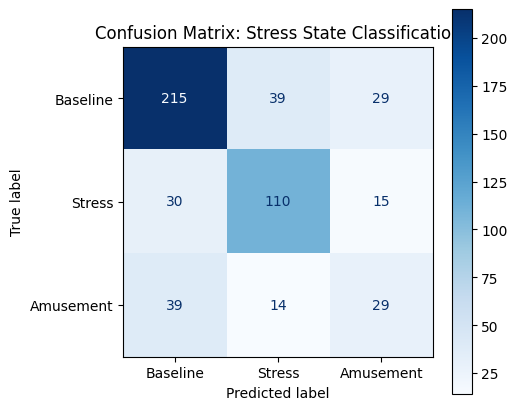

In [12]:
# Confusion matrix
# Which conditions get confused with which e.g., does the model confuse stress
# with amusement (both "aroused" states) more than either with baseline?

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = cross_val_predict(clf, X_all, y_all, cv=5)

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_all, y_pred, display_labels=['Baseline', 'Stress', 'Amusement'], ax=ax, cmap='Blues'
)
plt.title('Confusion Matrix: Stress State Classification')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation: Confusion matrix
Baseline: 215/283 correct (76%) - model is good at recognizing calm states. Stress: 110/155 correct (71%) - fairly strong. Amusement: 29/82 correct (35%) - clearly the weakest class (note: it is the smallest class (82 samples), thin data for this condition).

The confusion matrix shows baseline (76%) and stress (71%) are classified
reasonably well, while amusement is the weakest class (35% correct), most often
confused with baseline rather than stress. This is physiologically plausible:
amusement is a positive but comparatively mild arousal state, likely producing
a physiological signature that overlaps more with calm baseline than with the
more intense sympathetic activation of acute stress. The small sample size for
amusement (82 windows, the smallest class) likely also contributes to this
weaker performance.

In [13]:
# Feature Importance uing Random Forest
# Which of the 9 features mattered most?

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_all, y_all)

importances = rf.feature_importances_
for name, imp in sorted(zip(feature_names, importances), key=lambda x: -x[1]):
    print(f"{name}: {imp:.3f}")


heart_rate: 0.237
temp_mean: 0.169
eda_mean: 0.129
acc_mag_std: 0.110
eda_range: 0.105
eda_std: 0.084
acc_mag_mean: 0.067
temp_std: 0.058
hrv: 0.041


### Interpretation Random Forest feature importance
Result confirms that heart rate (the engineered
feature that drove earlier accuracy improvement) is the single most
predictive feature (importance: 0.237), followed by temperature and EDA mean.
Notably, heart rate variability (HRV) ranked lowest (0.041) despite its strong
association with stress in the literature; this likely reflects the limitations
of deriving HRV from wrist-based PPG over 60-second windows, which is less
precise than clinical-grade ECG-derived HRV typically used in stress research.

In [14]:
import pickle

# Train the final model on ALL available data (no train/test split needed here
# because we already evaluated it honestly via cross-validation; now I want
# the best possible model using every sample, since this is what the app will actually use)
final_scaler = StandardScaler()
X_scaled = final_scaler.fit_transform(X_all)

final_clf = SVC(kernel='linear', probability=True)  # probability=True lets us show confidence later
final_clf.fit(X_scaled, y_all)

# Save both the model and the scaler -- the app needs both to process new data correctly
with open('stress_model.pkl', 'wb') as f:
    pickle.dump(final_clf, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(final_scaler, f)

print("Model and scaler saved.")

Model and scaler saved.


In [15]:
# Export a few sample windows (raw signal segments) for the app to use
import json

# Grab one clear example of each condition from subject 2's data, for the app to use as samples
with open('/root/wesad_data/WESAD/S2/S2.pkl', 'rb') as f:
    s2_data = pickle.load(f, encoding='latin1')

eda_s2 = s2_data['signal']['wrist']['EDA'].flatten()
bvp_s2 = s2_data['signal']['wrist']['BVP'].flatten()
temp_s2 = s2_data['signal']['wrist']['TEMP'].flatten()
acc_s2 = s2_data['signal']['wrist']['ACC']
labels_s2 = s2_data['label']

fs_label = 700
fs_eda, fs_bvp, fs_temp, fs_acc = 4, 64, 4, 32

def get_clean_window(label_val, start_offset_sec=300):
    """Finds a 60-second window of a given condition, well inside its labeled region."""
    mask = labels_s2 == label_val
    onset_idx = np.argmax(mask)  # first index where this condition starts
    t_start = onset_idx / fs_label + start_offset_sec / 5  # a bit into the condition, not right at onset
    t_end = t_start + 60

    return {
        'eda': eda_s2[int(t_start*fs_eda):int(t_end*fs_eda)].tolist(),
        'bvp': bvp_s2[int(t_start*fs_bvp):int(t_end*fs_bvp)].tolist(),
        'temp': temp_s2[int(t_start*fs_temp):int(t_end*fs_temp)].tolist(),
        'acc': acc_s2[int(t_start*fs_acc):int(t_end*fs_acc)].tolist(),
    }

samples = {
    'Baseline example': get_clean_window(1),
    'Stress example': get_clean_window(2),
    'Amusement example': get_clean_window(3),
}

with open('sample_windows.json', 'w') as f:
    json.dump(samples, f)

print("Sample windows saved. Sizes:", {k: len(v['eda']) for k, v in samples.items()})

Sample windows saved. Sizes: {'Baseline example': 240, 'Stress example': 240, 'Amusement example': 240}


In [16]:
import json

with open('/root/wesad_data/WESAD/S2/S2.pkl', 'rb') as f:
    s2_data = pickle.load(f, encoding='latin1')

eda_s2 = s2_data['signal']['wrist']['EDA'].flatten()
bvp_s2 = s2_data['signal']['wrist']['BVP'].flatten()
temp_s2 = s2_data['signal']['wrist']['TEMP'].flatten()
acc_s2 = s2_data['signal']['wrist']['ACC']
labels_s2 = s2_data['label']

fs_label = 700
fs_eda, fs_bvp, fs_temp, fs_acc = 4, 64, 4, 32

def get_clean_window(label_val, offset_into_condition_sec=120):
    """
    Finds a 60-second window of a given condition, starting `offset_into_condition_sec`
    seconds after the condition begins -- gives the physiological response time to develop,
    rather than grabbing the very start of the condition.
    """
    mask = labels_s2 == label_val
    onset_idx = np.argmax(mask)
    onset_time_sec = onset_idx / fs_label

    t_start = onset_time_sec + offset_into_condition_sec
    t_end = t_start + 60

    return {
        'eda': eda_s2[int(t_start*fs_eda):int(t_end*fs_eda)].tolist(),
        'bvp': bvp_s2[int(t_start*fs_bvp):int(t_end*fs_bvp)].tolist(),
        'temp': temp_s2[int(t_start*fs_temp):int(t_end*fs_temp)].tolist(),
        'acc': acc_s2[int(t_start*fs_acc):int(t_end*fs_acc)].tolist(),
    }

samples = {
    'Baseline example': get_clean_window(1, offset_into_condition_sec=120),
    'Stress example': get_clean_window(2, offset_into_condition_sec=400),
    'Amusement example': get_clean_window(3, offset_into_condition_sec=120),
}

with open('sample_windows_2.json', 'w') as f:
    json.dump(samples, f)

print("Sample windows re-saved. Sizes:", {k: len(v['eda']) for k, v in samples.items()})

Sample windows re-saved. Sizes: {'Baseline example': 240, 'Stress example': 240, 'Amusement example': 240}


In [17]:
mask = labels_s2 == 2
stress_duration = mask.sum() / fs_label
print(f"Stress condition duration: {stress_duration:.0f} seconds")

Stress condition duration: 615 seconds
